In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import ClusterCentroids

from sklearn.cluster import KMeans
from collections import Counter

np.random.seed(0) # For reproducibility

## Part A: Data Exploration and Baseline Model

### Load and Analyze the Dataset

In [2]:
# Load the dataset
df = pd.read_csv(r"creditcard.csv")

print("Number of datapoints: ", df.shape[0])
print("Number of features: ", df.shape[1])

Number of datapoints:  284807
Number of features:  31


In [3]:
# Info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**The dataset has only numeric datatypes and has no null values**

In [4]:
# Description of the dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**The mean of the features V1-V28 is close to zero and the std is close to 1, as these features are PCA projected, the Time and Amount columns are left untouched**

### Analyze the Class Distribution

In [5]:
# Distribution of classes
num_frauds, num_non_frauds = sum(df['Class']), sum(1 - df['Class'])
print("Number of fraudulents: ", num_frauds)
print("Number of Non-Fraud: ", num_non_frauds)
print("\n")
print("Degree of Imbalance(Non-Fraud : Fraud ratio): ", num_non_frauds / num_frauds)

Number of fraudulents:  492
Number of Non-Fraud:  284315


Degree of Imbalance(Non-Fraud : Fraud ratio):  577.8760162601626


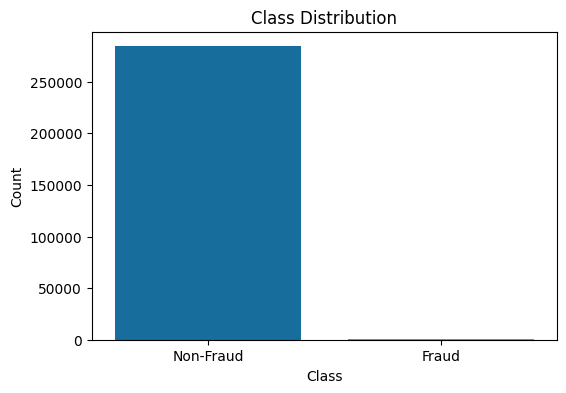

In [6]:
# Bar plot
class_counts = df['Class'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="colorblind", hue=class_counts.index, legend=False)
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

**The "Fraud-bar" is not even visible in the plot in comparison to the "Non-Fraud-bar"**

### Baseline Model

In [7]:
# Splitting the data, preserving class imbalance
X = np.array(df.drop("Class", axis=1))
y = np.array(df["Class"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

# Degree of Imbalance
print("Degree of Imbalance in Train set: ", sum(1 - y_train) / sum(y_train))
print("Degree of Imbalance in Test set: ", sum(1 - y_test) / sum(y_test))

Degree of Imbalance in Train set:  577.8753387533875
Degree of Imbalance in Test set:  577.8780487804878


In [8]:
# Baseline Model
baseline_model = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

In [9]:
print("Baseline Logistic Regression - Classification Report")
print("\n")
print(classification_report(y_test, y_pred_base, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_base))

Baseline Logistic Regression - Classification Report


              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     71079
           1     0.8526    0.6585    0.7431       123

    accuracy                         0.9992     71202
   macro avg     0.9260    0.8292    0.8714     71202
weighted avg     0.9992    0.9992    0.9992     71202

Accuracy: 0.9992135052386169


In [10]:
print("Number of fraudulent cases in Test data: ", sum(y_test))
print("Number of predicted fraudulent cases in Test data: ", sum(y_pred_base))

Number of fraudulent cases in Test data:  123
Number of predicted fraudulent cases in Test data:  95


**The Accuracy is not a good metric here, because the Degree of Imbalance is $\approx$ 578 i.e. there are 578 non-fraud cases per fraud case. So even if the model outputs 0 (predicts everyone as non-fraud), the accuracy would be around 578/579 $\approx$ 0.998. The better metrics to look at here would be recall (actual number of frauds catched) and precision (how reliable the model when the output is 1)**

## Part B: Resampling Approaches

### Naive Oversampling (SMOTE)

**SMOTE and Its Limitattions**

**SMOTE (Synthetic Minority Oversampling Technique)** is a method to handle class imbalance. Instead of duplicating existing minority samples, SMOTE **creates synthetic samples**:

1. For each minority class instance, SMOTE selects one of its *k* nearest neighbors (also from the minority class).  
2. A synthetic sample is generated as an interpolation (or a convex combination if you prefer) between the current sample and the chosen nearest neighbor sample.

Can be thought of as sampling points from the **Convex Hull** of the minority points.

**Limitations**:
1. If the minority points are from a distribution whose manifold is inherently non-convex, then SMOTE may sample points from regions where the density of the minority class is very low and leads to noise.
2. If the distribution of minority class is multi-modal, when the datapoints are sparse (as in the case of imbalance) SMOTE might generate many samples in the valley region between the modes, where the density of the minority class would be very low.

In [11]:
# Apply SMOTE to the dataset
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [12]:
# Degree of imbalance after SMOTE
print("Degree of Imbalance in Train set after SMOTE: ", sum(1 - y_train_sm) / sum(y_train_sm))

Degree of Imbalance in Train set after SMOTE:  1.0


### Clustering-Based Oversampling (CBO)

**Clustering-Based Oversampling (CBO)** instead of treating the minority class like a single group, it clusters them first and for each cluster it oversamples the points such that the degree of imbalance $\approx$ 1. This accounts for the multi-modal nature of the minority distribution and also it's non-convexity.

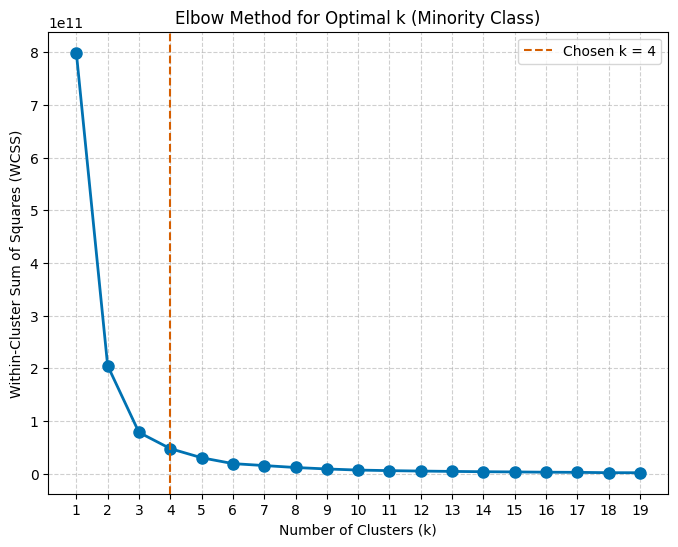

In [13]:
minority = X_train[y_train==1]

wc_ss = []
K = range(1, 20)
for i in K:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(minority)
    wc_ss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, wc_ss, 'o-', color="#0072B2", markersize=8, linewidth=2)
plt.xticks(K)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal k (Minority Class)")
plt.grid(True, linestyle="--", alpha=0.6)

optimal_k = 4
plt.axvline(x=optimal_k, color="#D55E00", linestyle="--", label=f"Chosen k = {optimal_k}")
plt.legend()
plt.show()

In [14]:
k_minor = 4
kmeans = KMeans(n_clusters=k_minor, random_state=0)
clusters = kmeans.fit_predict(minority)

X_minority_oversampled = []
y_minority_oversampled = []

# Target size of the minority class for each cluster
target_size = sum(y_train==0) // k_minor

for cluster_id in range(k_minor):
    cluster_samples = minority[clusters == cluster_id]
    n_samples_needed = target_size - len(cluster_samples)
    
    if n_samples_needed > 0:
        indices = np.random.choice(cluster_samples.shape[0], size=n_samples_needed, replace=True)
        resampled = cluster_samples[indices]
        X_minority_oversampled.append(np.concatenate([cluster_samples, resampled]))
    else:
        X_minority_oversampled.append(cluster_samples)
    
    y_minority_oversampled.append(np.array([1]*len(X_minority_oversampled[-1])))

X_minority_final = np.concatenate(X_minority_oversampled)
y_minority_final = np.concatenate(y_minority_oversampled)

# Combine with majority
X_majority = X_train[y_train==0]
y_majority = y_train[y_train==0]
X_train_cbo = np.concatenate([X_majority, X_minority_final])
y_train_cbo = np.concatenate([y_majority, y_minority_final])

In [15]:
# Degree of imbalance after CBO
print("Degree of Imbalance in Train set after CBO: ", sum(1 - y_train_cbo) / sum(y_train_cbo))

Degree of Imbalance in Train set after CBO:  1.0


### Clustering-Based Undersampling (CBU)

**Clustering-Based Undersampling (CBU)** handles class imbalance in a similar way to **CBO** but this decrease the size of the majority class instead of increasing the size of the minority class. Again it clusters the majority class and samples within each cluster to ensure that the undersampled data captures the distribution as good as the original data.

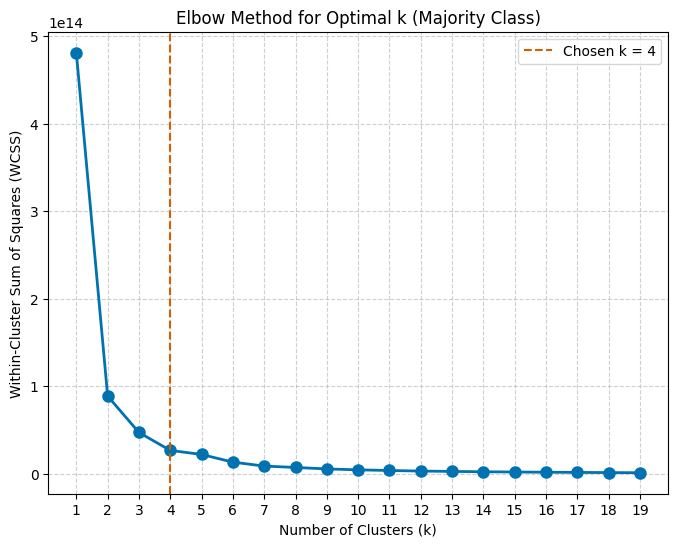

In [16]:
majority = X_train[y_train==0]

wc_ss = []
K = range(1, 20)
for i in K:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(majority)
    wc_ss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, wc_ss, 'o-', color="#0072B2", markersize=8, linewidth=2)
plt.xticks(K)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal k (Majority Class)")
plt.grid(True, linestyle="--", alpha=0.6)

optimal_k = 4
plt.axvline(x=optimal_k, color="#D55E00", linestyle="--", label=f"Chosen k = {optimal_k}")
plt.legend()
plt.show()

In [17]:
k_major = 4
kmeans_major = KMeans(n_clusters=k_major, random_state=42)
clusters_major = kmeans_major.fit_predict(majority)

# Undersample proportionally
target_majority_size = sum(y_train==1)
X_majority_sampled = []
y_majority_sampled = []

for cluster_id in range(k_major):
    cluster_samples = majority[clusters_major == cluster_id]
    n_samples_keep = int(len(cluster_samples) * target_majority_size / len(majority))
    indices = np.random.choice(cluster_samples.shape[0], size=n_samples_keep, replace=True)
    sampled = cluster_samples[indices]
    X_majority_sampled.append(sampled)
    y_majority_sampled.append(np.array([0]*n_samples_keep))

X_majority_final = np.concatenate(X_majority_sampled)
y_majority_final = np.concatenate(y_majority_sampled)

# Combine
X_minority = X_train[y_train==1]
y_minority = y_train[y_train==1]

X_train_cbu = np.concatenate([X_minority, X_majority_final])
y_train_cbu = np.concatenate([y_minority, y_majority_final])

In [18]:
# Degree of imbalance after CBU
print("Degree of Imbalance in Train set after CBU: ", sum(1 - y_train_cbo) / sum(y_train_cbo))

Degree of Imbalance in Train set after CBU:  1.0


## Model Comparison and Analysis

### Train and Evaluate Models

In [19]:
# With SMOTE
model_smote = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
model_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = model_smote.predict(X_test)

In [20]:
# With CBO
model_cbo = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
model_cbo.fit(X_train_cbo, y_train_cbo)
y_pred_cbo = model_cbo.predict(X_test)

In [21]:
# With CBU
model_cbu = LogisticRegression(max_iter=1000, random_state=0, solver="newton-cholesky")
model_cbu.fit(X_train_cbu, y_train_cbu)
y_pred_cbu = model_cbu.predict(X_test)

### Performance Comparison

In [22]:
# Collect predictions
models = {
    "Baseline": y_pred_base,
    "SMOTE": y_pred_smote,
    "CBO": y_pred_cbo,
    "CBU": y_pred_cbu
}

# Build summary table for both classes
rows = []
for name, preds in models.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average=None, labels=[0,1])
    rows.append([name, "Majority (0)", precision[0], recall[0], f1[0]])
    rows.append([name, "Minority (1)", precision[1], recall[1], f1[1]])

summary_df = pd.DataFrame(rows, columns=["Model","Class","Precision","Recall","F1-score"])
print(summary_df)

      Model         Class  Precision    Recall  F1-score
0  Baseline  Majority (0)   0.999409  0.999803  0.999606
1  Baseline  Minority (1)   0.852632  0.658537  0.743119
2     SMOTE  Majority (0)   0.999801  0.990729  0.995244
3     SMOTE  Minority (1)   0.141927  0.886179  0.244669
4       CBO  Majority (0)   0.999827  0.977884  0.988734
5       CBO  Minority (1)   0.065954  0.902439  0.122924
6       CBU  Majority (0)   0.999826  0.971046  0.985226
7       CBU  Minority (1)   0.051176  0.902439  0.096859


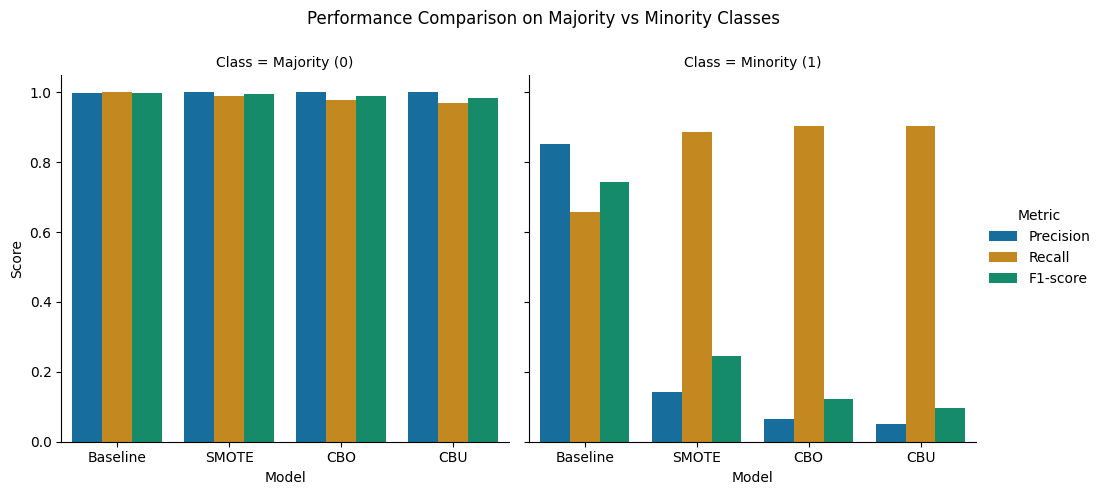

In [23]:
summary_melted = summary_df.melt(id_vars=["Model","Class"], var_name="Metric", value_name="Score")

g = sns.catplot(
    data=summary_melted,
    x="Model", y="Score", hue="Metric",
    col="Class",
    kind="bar",
    palette="colorblind",
    height=5, aspect=1
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Performance Comparison on Majority vs Minority Classes")
plt.show()

### Conclusion and Recommendations

**1. Baseline Model (Imbalanced Data)**  
- Performs very well on the **majority class (0)** with near-perfect Precision, Recall, and F1-score.  
- Performs **poorly on the minority class (1)** — recall is especially low, meaning most of the fraudulent cases are missed.  
- This confirms that accuracy alone is misleading in imbalanced datasets.

**2. SMOTE (Synthetic Oversampling)**  
- Significantly improves **recall** for the minority class compared to baseline.  
- However, **precision drops**, as some synthetic samples may overlap with majority class regions, creating false positives.  
- F1-score drops due to the drop in precision.

**3. Clustering-Based Oversampling (CBO)**  
- Recall performane is similar to SMOTE but the precision drops even more, which is interesting considering CBO is supposed to be less noisy that it doesn't sample from the low-density region. Either this may be to due to current seed I've set (A random 1 in million chance) or the clusters of positive and negative classes are too close, that CBO end up oversampling points near the boundary leading to some overlap

**4. Clustering-Based Undersampling (CBU)**  
- I can spot no significant difference from the CBO case.


**Recommendations**
**What sampling strategy to be used to tackle class-imbalance ?** : It depends on the use-case. As seen above these sampling strategies tend to improve the recall score significantly over the base model. So if your application is recall sensitive (That you need to capture all the frauds without leaving any single of them), you may try any one of them (I'd prefer CBO). But if your applicaton is precision sensitive (That the more the number of false positives you make, blocking non-fraudulent customers, more the backlash you get) you can get away with the baseline model in this case. Ultimately it's a trade-off between these two and you have to experiment with your data based on your needs to come up with a good strategy using your domain-knowledge as well.